In [ ]:
!pip install torchviz
!pip install torchsummary
!pip  install torchinfo

In [ ]:

!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
from glob import glob
import random


In [ ]:
# prompt: mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mode ="Adapt"# "Train" # "Retrain", "Adapt"
current_model_name = 'Featurenet_3'
model_path = '/content/drive/MyDrive/Projects/AR_CAM/Models'
PIN_MEMORY = True  # recommended for GPU training

In [ ]:
# prompt: add gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ------------------------------------------
# 1. Hyperparameters & Configuration
# ------------------------------------------
DATASET_DIR = "/content/drive/MyDrive/Projects/AR_CAM/dataset2/synthetic"
RESOLUTION = 128
BATCH_SIZE = 6 # Reduced batch size to mitigate OOM errors
EPOCHS = 0  #54
LEARNING_RATE = 1e-3
NUM_WORKERS = 4
TRAIN_SPLIT = 0
VAL_SPLIT = 0
TEST_SPLIT = 1
SEED = 42
ADAPT_LR = 1e-3
RE_LEARNING_RATE = 1e-4
torch.manual_seed(SEED)
random.seed(10)

In [ ]:

# ------------------------------------------
# 2. Dataset Class
# ------------------------------------------
class VoxelDataset(Dataset):
    def __init__(self, data_files, label_map):
        self.files = data_files
        self.label_map = label_map

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        voxel = np.load(path).astype(np.float32)
        voxel = voxel[np.newaxis, :, :, :]  # shape = [1, D, H, W]
        class_name = os.path.basename(os.path.dirname(path))
        label = self.label_map[class_name]
        return torch.tensor(voxel), torch.tensor(label)


In [ ]:

# ------------------------------------------
# 3. Data Preparation
# ------------------------------------------
# Get all files and build label map
class_folders = [f for f in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, f))]
label_map = {name: idx for idx, name in enumerate(sorted(class_folders))}
all_files = []

for cls in class_folders:
    files = glob(os.path.join(DATASET_DIR, cls, '*.npy'))
    print(len(files))
    all_files.extend(files)

random.shuffle(all_files)
total = len(all_files)
train_len = int(total * TRAIN_SPLIT)
val_len = int(total * VAL_SPLIT)
test_len = int(total * TEST_SPLIT)

dataset = VoxelDataset(all_files, label_map)
train_set, val_set, test_set, _ = random_split(dataset, [train_len, val_len, test_len, total - (train_len + val_len + test_len)])

# train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,prefetch_factor=2)
# val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)

1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000


In [ ]:

# ------------------------------------------
# 3b. Data Preparation
# ------------------------------------------
if mode == "Adapt":
    # Get all files and build label map
    REAL_DATASET_DIR = "/content/drive/MyDrive/Projects/AR_CAM/dataset2/noisy"

    class_folders = [f for f in os.listdir(REAL_DATASET_DIR) if os.path.isdir(os.path.join(REAL_DATASET_DIR, f))]
    label_map = {name: idx for idx, name in enumerate(sorted(class_folders))}
    all_files = []

    for cls in class_folders:
        files = glob(os.path.join(REAL_DATASET_DIR, cls, '*.npy'))
        print(len(files))
        all_files.extend(files)


    random.shuffle(all_files)
    total = len(all_files)
    train_len = int(total * TRAIN_SPLIT)
    val_len = int(total * VAL_SPLIT)
    test_len = int(total * TEST_SPLIT)

    dataset = VoxelDataset(all_files, label_map)
    train_set, val_set, test_set, _ = random_split(dataset, [train_len, val_len, test_len, total - (train_len + val_len + test_len)])

    # train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,prefetch_factor=2)
    # val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)

300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300
300


In [ ]:
# # ------------------------------------------
# # Combine Validation and Test Sets for Full Test
# # ------------------------------------------
# full_test_set = torch.utils.data.ConcatDataset([val_set, test_set])
# full_test_loader = DataLoader(full_test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)

# print(f"Full test set size: {len(full_test_set)}")

Full test set size: 2160


In [ ]:
# random.seed(7)
# random.shuffle(all_files)
# dataset = VoxelDataset(all_files, label_map)
# train_set, val_set, test_set, _ = random_split(dataset, [train_len, val_len, test_len, total - (train_len + val_len + test_len)])

# train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,prefetch_factor=2)
# val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)
# test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)

In [ ]:
len(all_files)

7200

In [ ]:

# ------------------------------------------
# 4. FeatureNet-like 3D CNN Model
# ------------------------------------------
class FeatureNet3D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),  # 64³

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2),  # 32³

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d(2),  # 16³

            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))  # Global pooling
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [ ]:
# ------------------------------------------
# 5. Training & Evaluation Utilities
# ------------------------------------------
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy



def evaluate(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            out = model(x)
            _, pred = torch.max(out, 1)
            preds.extend(pred.cpu().numpy())
            labels.extend(y.numpy())
    return preds, labels


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [ ]:
#import gc
#del model
#torch.cuda.empty_cache()
#gc.collect()

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 📂 Path for loading/saving
full_model_path = os.path.join(model_path, f"{current_model_name}.pth")
criterion = nn.CrossEntropyLoss()

In [ ]:
# -----------------------------------------
# 6. Run Training
# ------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 📂 Path for loading/saving
full_model_path = os.path.join(model_path, f"{current_model_name}.pth")
criterion = nn.CrossEntropyLoss()

# -----------------------------
# A. Train
# -----------------------------
model = FeatureNet3D(num_classes=len(label_map)).to(device)
if mode == "Train":
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)



# -----------------------------
# B. Retrain (load weights first)
# -----------------------------
elif mode == "Retrain":
    print(f"♻️ Retraining: loading model from {full_model_path}")
    checkpoint = torch.load(full_model_path)
    optimizer = torch.optim.Adam(model.parameters(), lr=RE_LEARNING_RATE)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Change LR after loading optimizer state
    for param_group in optimizer.param_groups:
        param_group['lr'] = RE_LEARNING_RATE  # your new learning rate

    start_epoch = checkpoint['epoch'] + 1
    model.train()




# -----------------------------
# C. Adapt to new domain (fine-tune)
# -----------------------------
elif mode == "Adapt":
    # ------------------------------------------
    # Real Dataset for Training/Validation on noisy
    # ------------------------------------------
    # REAL_DATASET_DIR = "/content/drive/MyDrive/Projects/AR_CAM/dataset2/noisy"
    # class_folders = [f for f in os.listdir(REAL_DATASET_DIR) if os.path.isdir(os.path.join(REAL_DATASET_DIR, f))]
    # label_map = {name: idx for idx, name in enumerate(sorted(class_folders))}

    # all_files = []
    # for cls in class_folders:
    #     files = glob(os.path.join(REAL_DATASET_DIR, cls, '*.npy'))
    #     all_files.extend(files)

    # random.shuffle(all_files)
    # total = len(all_files)
    # train_len = int(total * TRAIN_SPLIT)
    # val_len = total - train_len  # here we only split train/val from REAL

    # dataset = VoxelDataset(all_files, label_map)
    # train_set, val_set, test_set, _ = random_split(
    #     dataset,
    #     [train_len, val_len, test_len, total - (train_len + val_len + test_len)]
    # )


    # train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,prefetch_factor=2)
    # val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)
    # test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)



    print(f"🌍 Domain Adaptation: loading pretrained model from {full_model_path}")

    model = FeatureNet3D(num_classes=len(label_map)).to(device)
    checkpoint = torch.load(full_model_path, map_location=device)

    # Handle both dict-only saves and checkpoint dicts
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last conv block + classifier for adaptation
    for name, param in model.named_parameters():
        if "conv4" in name or "classifier" in name:
            param.requires_grad = True

    # Use small LR for fine-tuning
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=ADAPT_LR  # e.g., 1e-4
    )

    criterion = nn.CrossEntropyLoss()
    start_epoch = 0
    model.train()
    full_model_path = os.path.join(model_path, f"{current_model_name}_adapted.pth")

else:
    raise ValueError(f" Unknown mode: {mode}")

🌍 Domain Adaptation: loading pretrained model from /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_3.pth


In [ ]:
# # Set the environment variable before running the script
# import os
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# # This is typically set before the Python process starts, e.g., in the shell

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


Evaluating on Noisy Dataset:

Noisy Dataset Accuracy: 0.9398

Classification Report (Noisy Dataset):
                               precision    recall  f1-score   support

                     0_Oring     1.0000    0.8778    0.9349        90
       10_rectangular_pocket     1.0000    0.8571    0.9231        84
      11_circular_end_pocket     0.9667    1.0000    0.9831        87
    12_triangular_blind_step     0.8235    1.0000    0.9032        84
      13_circular_blind_step     0.9762    0.9213    0.9480        89
   14_rectangular_blind_step     0.9000    0.9677    0.9326        93
 15_rectangular_through_step     0.9583    0.7340    0.8313        94
      16_2sides_through_step     0.7034    0.9651    0.8137        86
     17_slanted_through_step     0.7460    0.9592    0.8393        98
                  18_chamfer     0.9647    0.9880    0.9762        83
                    19_round     0.9753    1.0000    0.9875        79
              1_through_hole     1.0000    0.9510    0.9

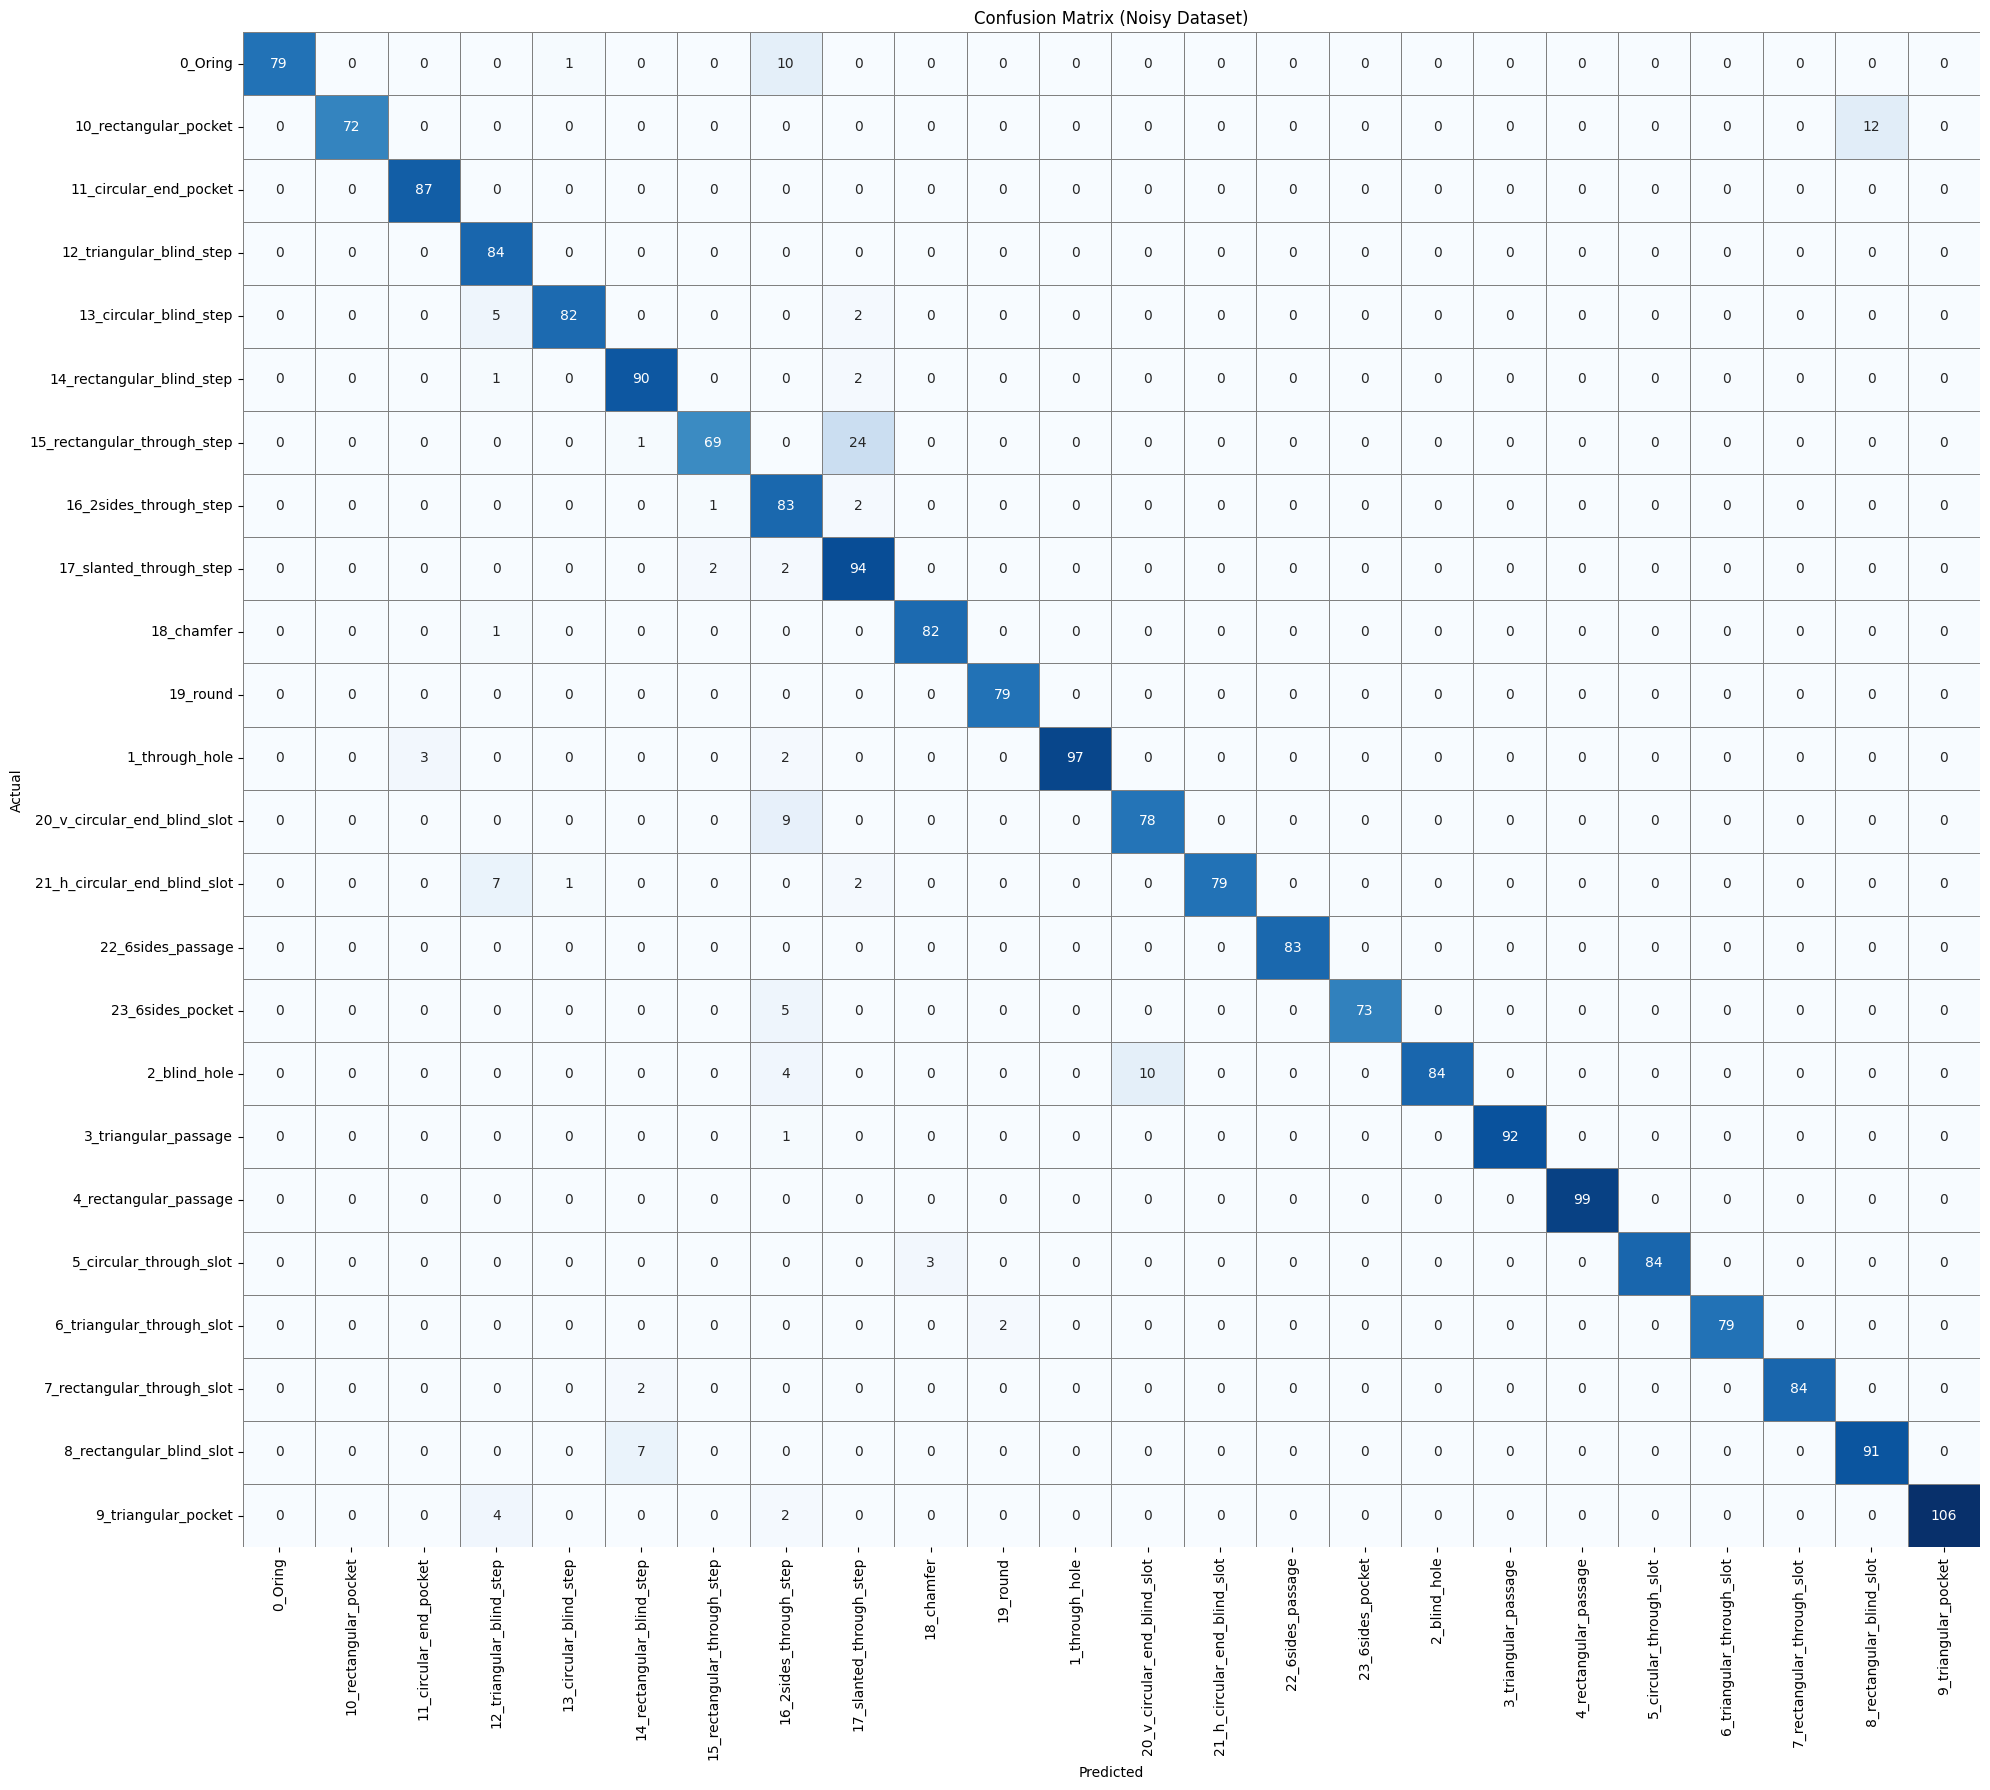

In [ ]:
if mode == "Adapt":
    print("\nEvaluating on Noisy Dataset:")
    preds_noisy, labels_noisy = evaluate(model, full_test_loader, device) # Use test_loader which is loaded with noisy data in Adapt mode

    # Calculate accuracy
    accuracy_noisy = accuracy_score(labels_noisy, preds_noisy)
    print(f"\nNoisy Dataset Accuracy: {accuracy_noisy:.4f}")

    print("\nClassification Report (Noisy Dataset):\n", classification_report(labels_noisy, preds_noisy, target_names=label_map.keys(), digits=4))

    # Confusion matrix (formatted)
    cm_noisy = confusion_matrix(labels_noisy, preds_noisy)
    cm_df_noisy = pd.DataFrame(cm_noisy, index=label_map.keys(), columns=label_map.keys())

    # Display as heatmap
    plt.figure(figsize=(20,18))
    sns.heatmap(cm_df_noisy, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='gray')
    plt.title('Confusion Matrix (Noisy Dataset)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

## Stop

In [ ]:
import time
import pandas as pd

In [ ]:
if mode == "Train":

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    start_epoch = 0
    end_epoch = EPOCHS

elif mode == "Retrain":
    # Construct the full path to the training history CSV
    end_epoch =  EPOCHS + start_epoch
    csv_filename = f"{current_model_name}_training_history.csv"
    csv_path = os.path.join(model_path, csv_filename)

    # Read the CSV into a pandas DataFrame
    df_history_loaded = pd.read_csv(csv_path)

    # Convert the DataFrame to a dictionary
    history = df_history_loaded.to_dict(orient='list')

In [ ]:
end_epoch

59

In [ ]:
start_time = time.time()

# your code block here

for epoch in range(start_epoch, end_epoch):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Save to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{end_epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%  ") #
    print(f" Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    torch.cuda.empty_cache()

    full_model_path = os.path.join(model_path, f"{current_model_name}.pth")

    torch.save({
        'epoch': epoch,  # replace with your current epoch variable
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': train_loss  # replace with your loss variable if you track it
    }, full_model_path)

    print(f"Checkpoint saved to {full_model_path}")
    df_history = pd.DataFrame(history)

    # Construct full path
    csv_filename = f"{current_model_name}_training_history.csv"
    csv_path = os.path.join(model_path, csv_filename)

    # Save the file
    df_history.to_csv(csv_path, index=False)
    print(f"✅ Training history saved to {csv_path}")




end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.2f} seconds")

Epoch 4/59 | Train Loss: 0.2099 | Train Acc: 94.38%  
 Val Loss: 0.1845 | Val Acc: 94.88%
Checkpoint saved to /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_2.pth
✅ Training history saved to /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_2_training_history.csv
Epoch 5/59 | Train Loss: 0.1902 | Train Acc: 94.86%  
 Val Loss: 0.1724 | Val Acc: 94.88%
Checkpoint saved to /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_2.pth
✅ Training history saved to /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_2_training_history.csv
Epoch 6/59 | Train Loss: 0.1732 | Train Acc: 95.37%  
 Val Loss: 0.2045 | Val Acc: 93.46%
Checkpoint saved to /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_2.pth
✅ Training history saved to /content/drive/MyDrive/Projects/AR_CAM/Models/Featurenet_2_training_history.csv
Epoch 7/59 | Train Loss: 0.1607 | Train Acc: 95.68%  
 Val Loss: 0.1408 | Val Acc: 96.38%
Checkpoint saved to /content/drive/MyDrive/Projects/AR_CAM/Models/F

KeyboardInterrupt: 

In [ ]:
# val_loss, val_acc = validate(model, val_loader, criterion, device)

In [ ]:
# history['val_loss'].append(val_loss)
# history['val_acc'].append(val_acc)

In [ ]:
# print(f"Epoch {epoch+1}/{end_epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%  ")

In [ ]:
start_epoch

NameError: name 'start_epoch' is not defined

In [ ]:
# prompt: add accuracy use import the accuracy

from sklearn.metrics import accuracy_score

# ------------------------------------------
# 7. Final Evaluation
# ------------------------------------------
preds, labels = evaluate(model, test_loader, device)



NameError: name 'evaluate' is not defined

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(labels, preds)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(labels, preds, target_names=label_map.keys(), digits=4))
# print("Confusion Matrix:\n", confusion_matrix(labels, preds))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Confusion matrix (formatted)
cm = confusion_matrix(labels, preds)
cm_df = pd.DataFrame(cm, index=label_map.keys(), columns=label_map.keys())

# 3. Display as heatmap
plt.figure(figsize=(20,18))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='gray')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## on real data

In [ ]:
# # ------------------------------------------
# # Separate Dataset for Testing_2 on real
# # ------------------------------------------
# TEST_DATASET_DIR = "/content/drive/MyDrive/Projects/AR_CAM/dataset2/real"
# test_class_folders = [f for f in os.listdir(TEST_DATASET_DIR) if os.path.isdir(os.path.join(TEST_DATASET_DIR, f))]
# # Make sure test dataset uses the SAME label mapping
# test_files = []
# for cls in test_class_folders:
#     if cls not in label_map:
#         raise ValueError(f"Class '{cls}' in test dataset not found in training label map!")
#     files = glob(os.path.join(TEST_DATASET_DIR, cls, '*.npy'))
#     test_files.extend(files)

# test_dataset_2 = VoxelDataset(test_files, label_map)
# test_loader_2  = DataLoader(test_dataset_2, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:

# from sklearn.metrics import accuracy_score

# # ------------------------------------------
# # 7. Final Evaluation
# # ------------------------------------------
# preds_2, labels_2 = evaluate(model, test_loader_2, device)


In [ ]:
# # Calculate accuracy
# accuracy = accuracy_score(labels_2, preds_2)
# print(f"\nTest Accuracy: {accuracy:.4f}")

# print("\nClassification Report:\n", classification_report(labels_2, preds_2, target_names=label_map.keys(), digits=4))
# # print("Confusion Matrix:\n", confusion_matrix(labels, preds))


In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 2. Confusion matrix (formatted)
# cm = confusion_matrix(labels_2, preds_2)
# cm_df = pd.DataFrame(cm, index=label_map.keys(), columns=label_map.keys())

# # 3. Display as heatmap
# plt.figure(figsize=(20,18))
# sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='gray')
# plt.title('Confusion Matrix')
# plt.ylabel('Actual')
# plt.xlabel('Predicted')
# plt.tight_layout()
# plt.show()

### End of Real data

In [ ]:
# model_path = '/content/drive/MyDrive/Projects/AR_CAM/Models'

In [ ]:
# ------------------------------------------
# 8. Save the trained model (for retraining or evaluation)
# ------------------------------------------
full_model_path = os.path.join(model_path, f"{current_model_name}.pth")

torch.save({
    'epoch': epoch,  # replace with your current epoch variable
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_loss  # replace with your loss variable if you track it
}, full_model_path)

print(f"Checkpoint saved to {full_model_path}")


In [ ]:
import json

# Define the path to save the label map
label_map_path = os.path.join(model_path, f"{current_model_name}_label_map.json")

# Save the label map to a JSON file
with open(label_map_path, 'w') as f:
    json.dump(label_map, f)

print(f"Label map saved to {label_map_path}")

## Load and Use Model

In [ ]:
# ## For Future Use
# # Instantiate your model
# # Make sure the model architecture (FeatureNet3D in this case) is the same as the saved model


# model = FeatureNet3D(num_classes=len(label_map)).to(device)

# # # Load the saved state dictionary
# checkpoint = torch.load(full_model_path)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()  # switch to inference mode

# print(f"Model loaded successfully from {full_model_path}")

In [ ]:
preds, labels = evaluate(model, full_test_loader, device)
# Calculate accuracy
accuracy = accuracy_score(labels, preds)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(labels, preds, target_names=label_map.keys(), digits=4))
# print("Confusion Matrix:\n", confusion_matrix(labels, preds))

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Confusion matrix (formatted)
cm = confusion_matrix(labels, preds)
cm_df = pd.DataFrame(cm, index=label_map.keys(), columns=label_map.keys())

# 3. Display as heatmap
plt.figure(figsize=(20,18))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='gray')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------
# Create a DataLoader for the full dataset
# ------------------------------------------
full_dataset = VoxelDataset(all_files, label_map)
full_dataset_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, prefetch_factor=2)

print(f"Full dataset size: {len(full_dataset)}")

In [ ]:
preds, labels = evaluate(model, full_dataset_loader, device)
# Calculate accuracy
accuracy = accuracy_score(labels, preds)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(labels, preds, target_names=label_map.keys(), digits=4))
# print("Confusion Matrix:\n", confusion_matrix(labels, preds))

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Confusion matrix (formatted)
cm = confusion_matrix(labels, preds)
cm_df = pd.DataFrame(cm, index=label_map.keys(), columns=label_map.keys())

# 3. Display as heatmap
plt.figure(figsize=(20,18))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='gray')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Show model design

In [ ]:
# Get one batch from your DataLoader
sample_batch = next(iter(train_loader))

# Unpack it: voxel, label
sample_input, _ = sample_batch

# Move to device (e.g., CUDA)
sample_input = sample_input.to(device)

torch.onnx.export(
    model,
    sample_input,                      # Use actual input
    "FeatureNet3D.onnx",
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Model exported to FeatureNet3D.onnx using actual sample input.")


In [ ]:
from torchviz import make_dot

# model = FeatureNet3D(num_classes=24).to(device)

y = model(sample_input)

make_dot(y, params=dict(model.named_parameters())).render("FeatureNet3D_graph", format="png")


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.show()




In [ ]:
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()

In [ ]:
#

In [ ]:
import os
import pandas as pd
# Convert history dictionary to DataFrame
df_history = pd.DataFrame(history)

# Construct full path
csv_filename = f"{current_model_name}_training_history.csv"
csv_path = os.path.join(model_path, csv_filename)

# Save the file
df_history.to_csv(csv_path, index=False)
print(f"✅ Training history saved to {csv_path}")


In [ ]:
from torchinfo import summary  # pip install torchinfo

# Example for a 3D CNN with batch size 2, 1 channel, 128³ voxel input
summary(model, input_size=(6, 1,128,128,128))